In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import os
import random
import seaborn as sns
import PIL

from keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

from keras import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense

# 1. Load Data

In [165]:
data_dir = "C:/Users/Admin/Desktop/22-Machine_Learning-Projects/data"

input_path = []
label = []

for class_name in os.listdir(f"{data_dir}/6_ImageClassificationSystem/PetImages"):
    for path in os.listdir(f"{data_dir}/6_ImageClassificationSystem/PetImages/" + class_name):
        if class_name == 'Cat':
            label.append(0)
        if class_name == 'Dog':
            label.append(1)
        input_path.append(os.path.join(f"{data_dir}/6_ImageClassificationSystem/PetImages", class_name, path))

print(input_path[0], label[0])

C:/Users/Admin/Desktop/22-Machine_Learning-Projects/data/6_ImageClassificationSystem/PetImages\Cat\0.jpg 0


In [166]:
df = pd.DataFrame()
df['images'] = input_path
df['label'] = label
df = df.sample(frac=1).reset_index(drop=True)
df

,images,label
0,C:/Users/Admin/Desktop/22-Machine_Learning-Pro...,0
1,C:/Users/Admin/Desktop/22-Machine_Learning-Pro...,0
2,C:/Users/Admin/Desktop/22-Machine_Learning-Pro...,0
3,C:/Users/Admin/Desktop/22-Machine_Learning-Pro...,0
4,C:/Users/Admin/Desktop/22-Machine_Learning-Pro...,1
...,...,...
24997,C:/Users/Admin/Desktop/22-Machine_Learning-Pro...,0
24998,C:/Users/Admin/Desktop/22-Machine_Learning-Pro...,0
24999,C:/Users/Admin/Desktop/22-Machine_Learning-Pro...,1
25000,C:/Users/Admin/Desktop/22-Machine_Learning-Pro...,0


In [167]:
# delete db files
for i in df['images']:
    if '.jpg' not in i:
        print(i)

C:/Users/Admin/Desktop/22-Machine_Learning-Projects/data/6_ImageClassificationSystem/PetImages\Cat\Thumbs.db
C:/Users/Admin/Desktop/22-Machine_Learning-Projects/data/6_ImageClassificationSystem/PetImages\Dog\Thumbs.db


In [168]:
l = []
for image in df['images']:
    try:
        img = PIL.Image.open(image)
    except:
        l.append(image)
l

['C:/Users/Admin/Desktop/22-Machine_Learning-Projects/data/6_ImageClassificationSystem/PetImages\\Cat\\666.jpg',
 'C:/Users/Admin/Desktop/22-Machine_Learning-Projects/data/6_ImageClassificationSystem/PetImages\\Cat\\Thumbs.db',
 'C:/Users/Admin/Desktop/22-Machine_Learning-Projects/data/6_ImageClassificationSystem/PetImages\\Dog\\Thumbs.db',
 'C:/Users/Admin/Desktop/22-Machine_Learning-Projects/data/6_ImageClassificationSystem/PetImages\\Dog\\11702.jpg']

In [169]:
# continue delete db files
df = df[df['images'] != 'C:/Users/Admin/Desktop/22-Machine_Learning-Projects/data/6_ImageClassificationSystem/PetImages\Dog\Thumbs.db']
df = df[df['images'] != 'C:/Users/Admin/Desktop/22-Machine_Learning-Projects/data/6_ImageClassificationSystem/PetImages\Cat\Thumbs.db']
df = df[df['images'] != 'C:/Users/Admin/Desktop/22-Machine_Learning-Projects/data/6_ImageClassificationSystem/PetImages\\Cat\\666.jpg']
df = df[df['images'] != 'C:/Users/Admin/Desktop/22-Machine_Learning-Projects/data/6_ImageClassificationSystem/PetImages\\Dog\\11702.jpg']
len(df)

24998

In [170]:
# continue delete db files
df = df[df['images'] != 'C:/Users/Admin/Desktop/22-Machine_Learning-Projects/data/6_ImageClassificationSystem/PetImages\Dog\Thumbs.db']
df = df[df['images'] != 'C:/Users/Admin/Desktop/22-Machine_Learning-Projects/data/6_ImageClassificationSystem/PetImages\Cat\Thumbs.db']
len(df)

24998

# 2. Exploratory Data Analysis

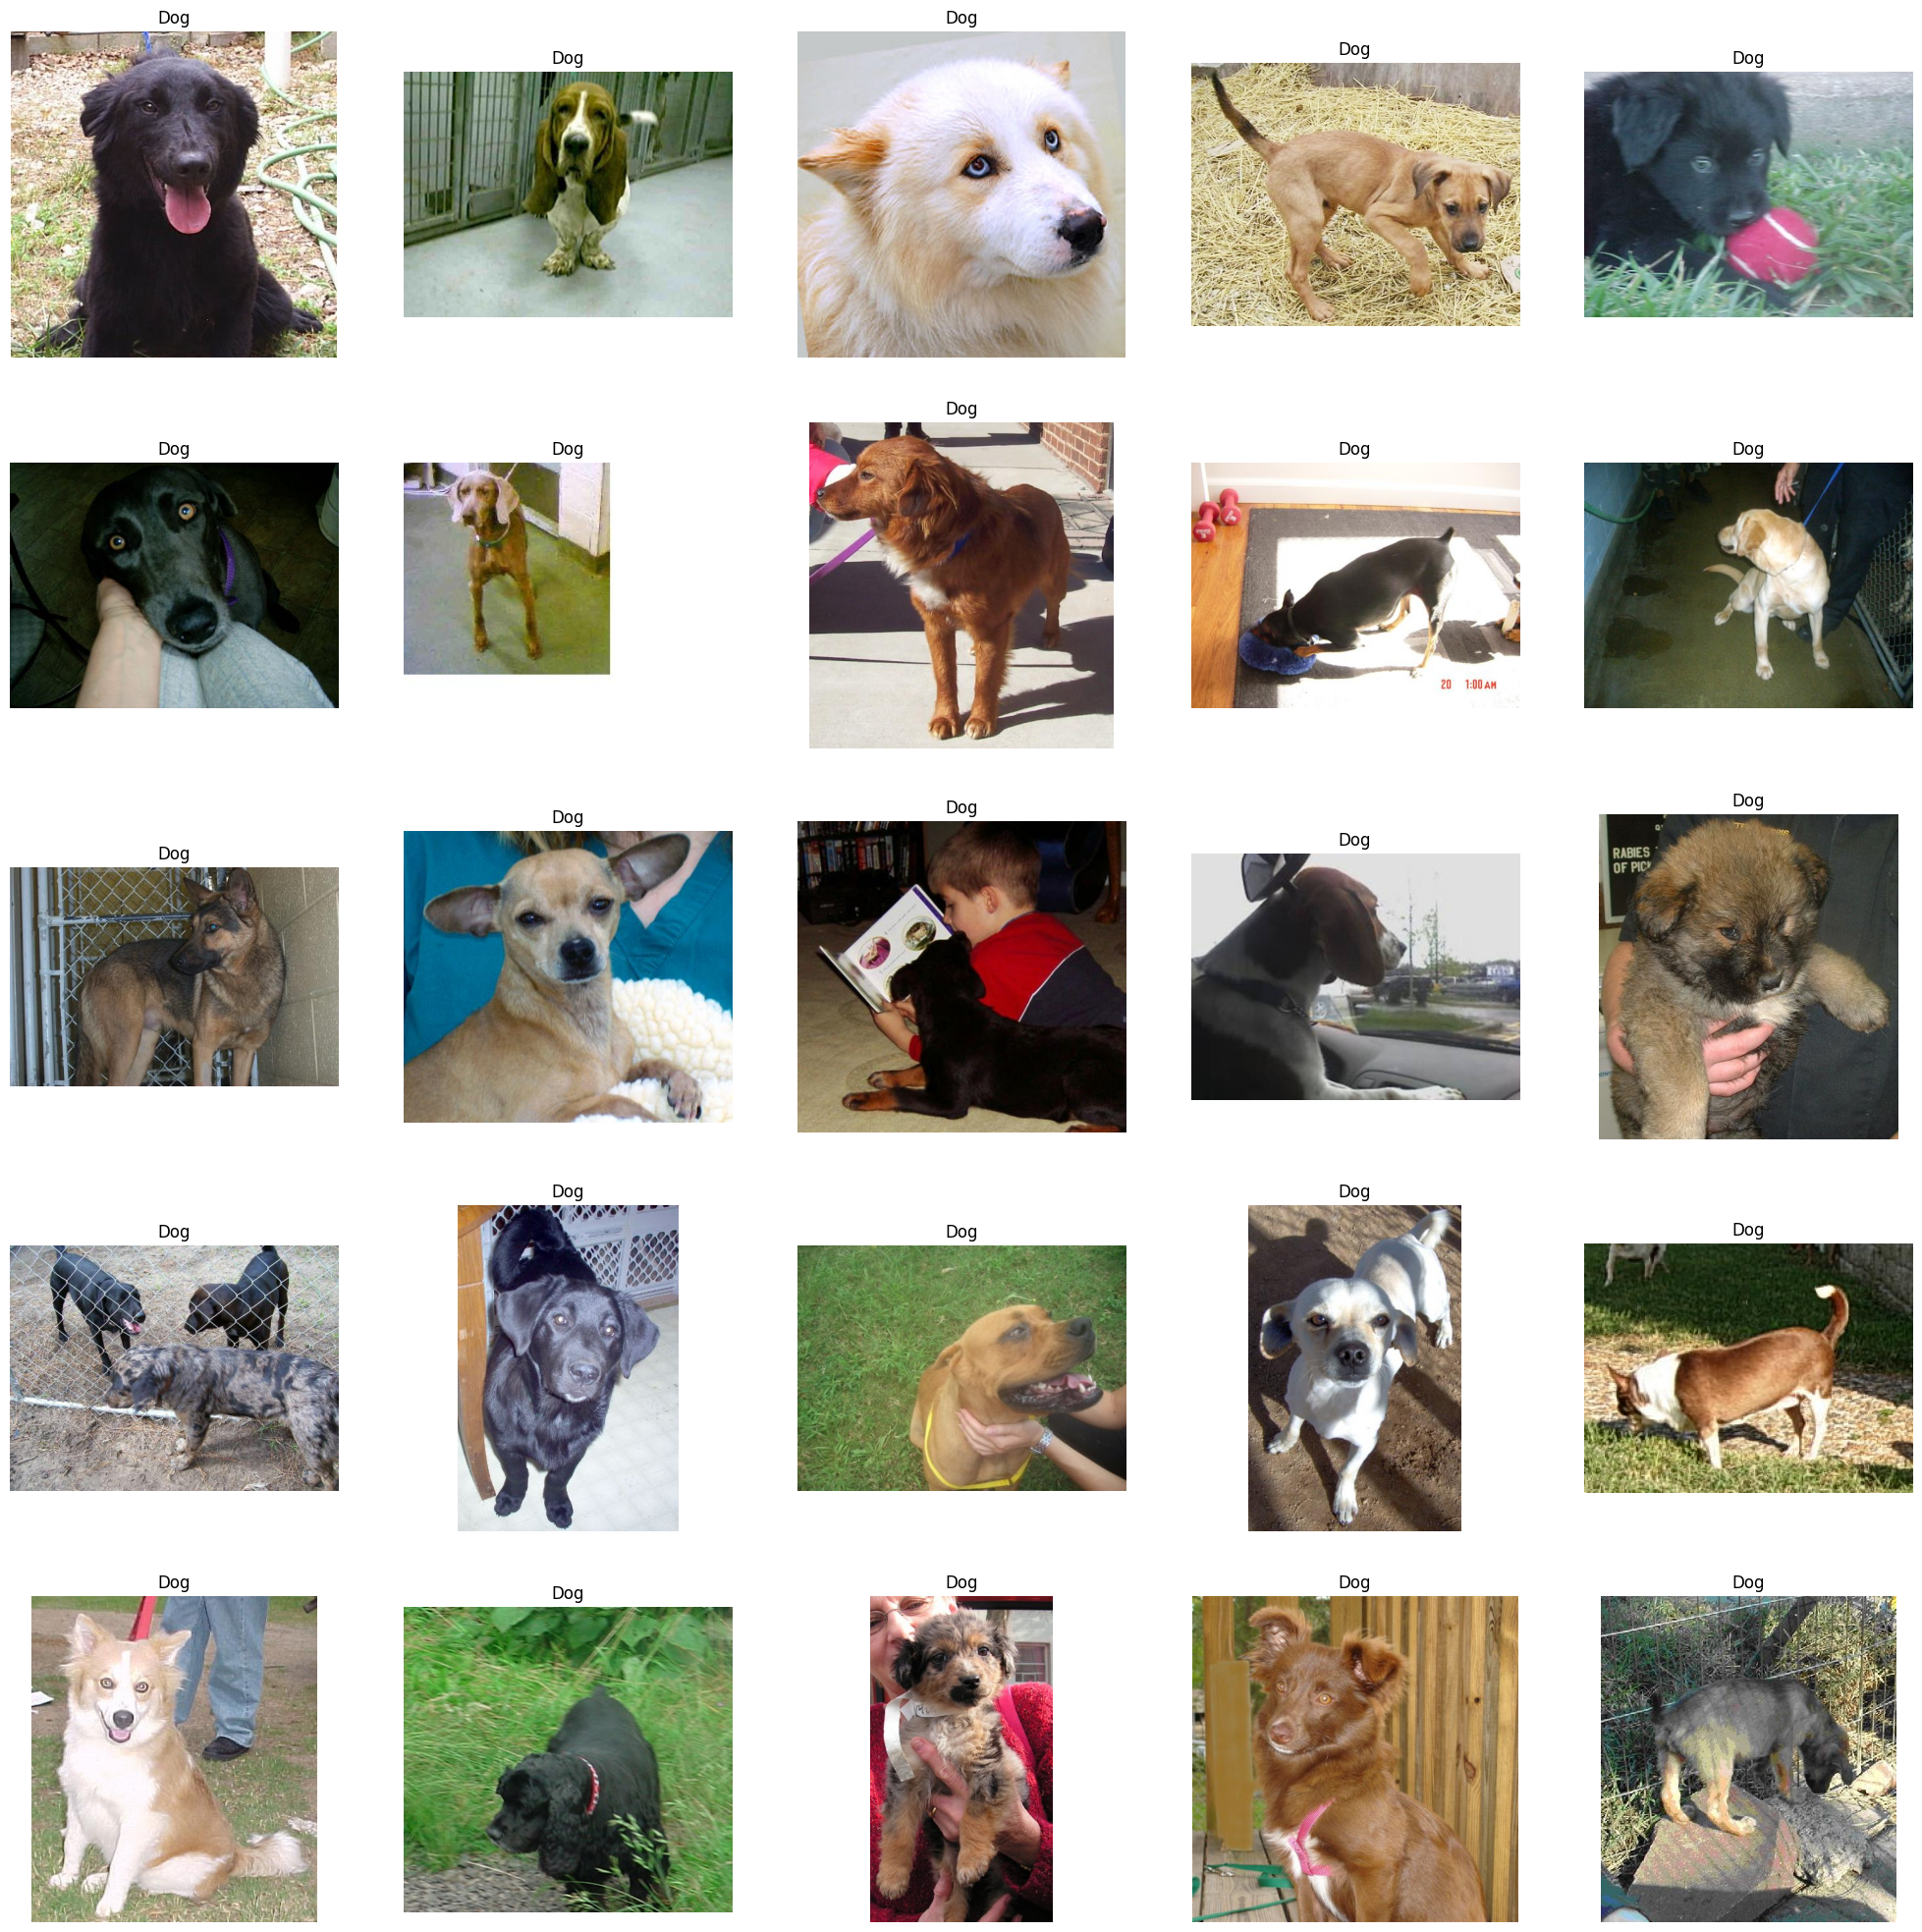

In [171]:
# Display grids of images
plt.figure(figsize=(25,25))
temp = df[df['label'] == 1]['images']
start = random.randint(0, len(temp))
files = temp[start:start+25]

for index, file in enumerate(files):
    plt.subplot(5, 5, index + 1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title('Dog')
    plt.axis('off')

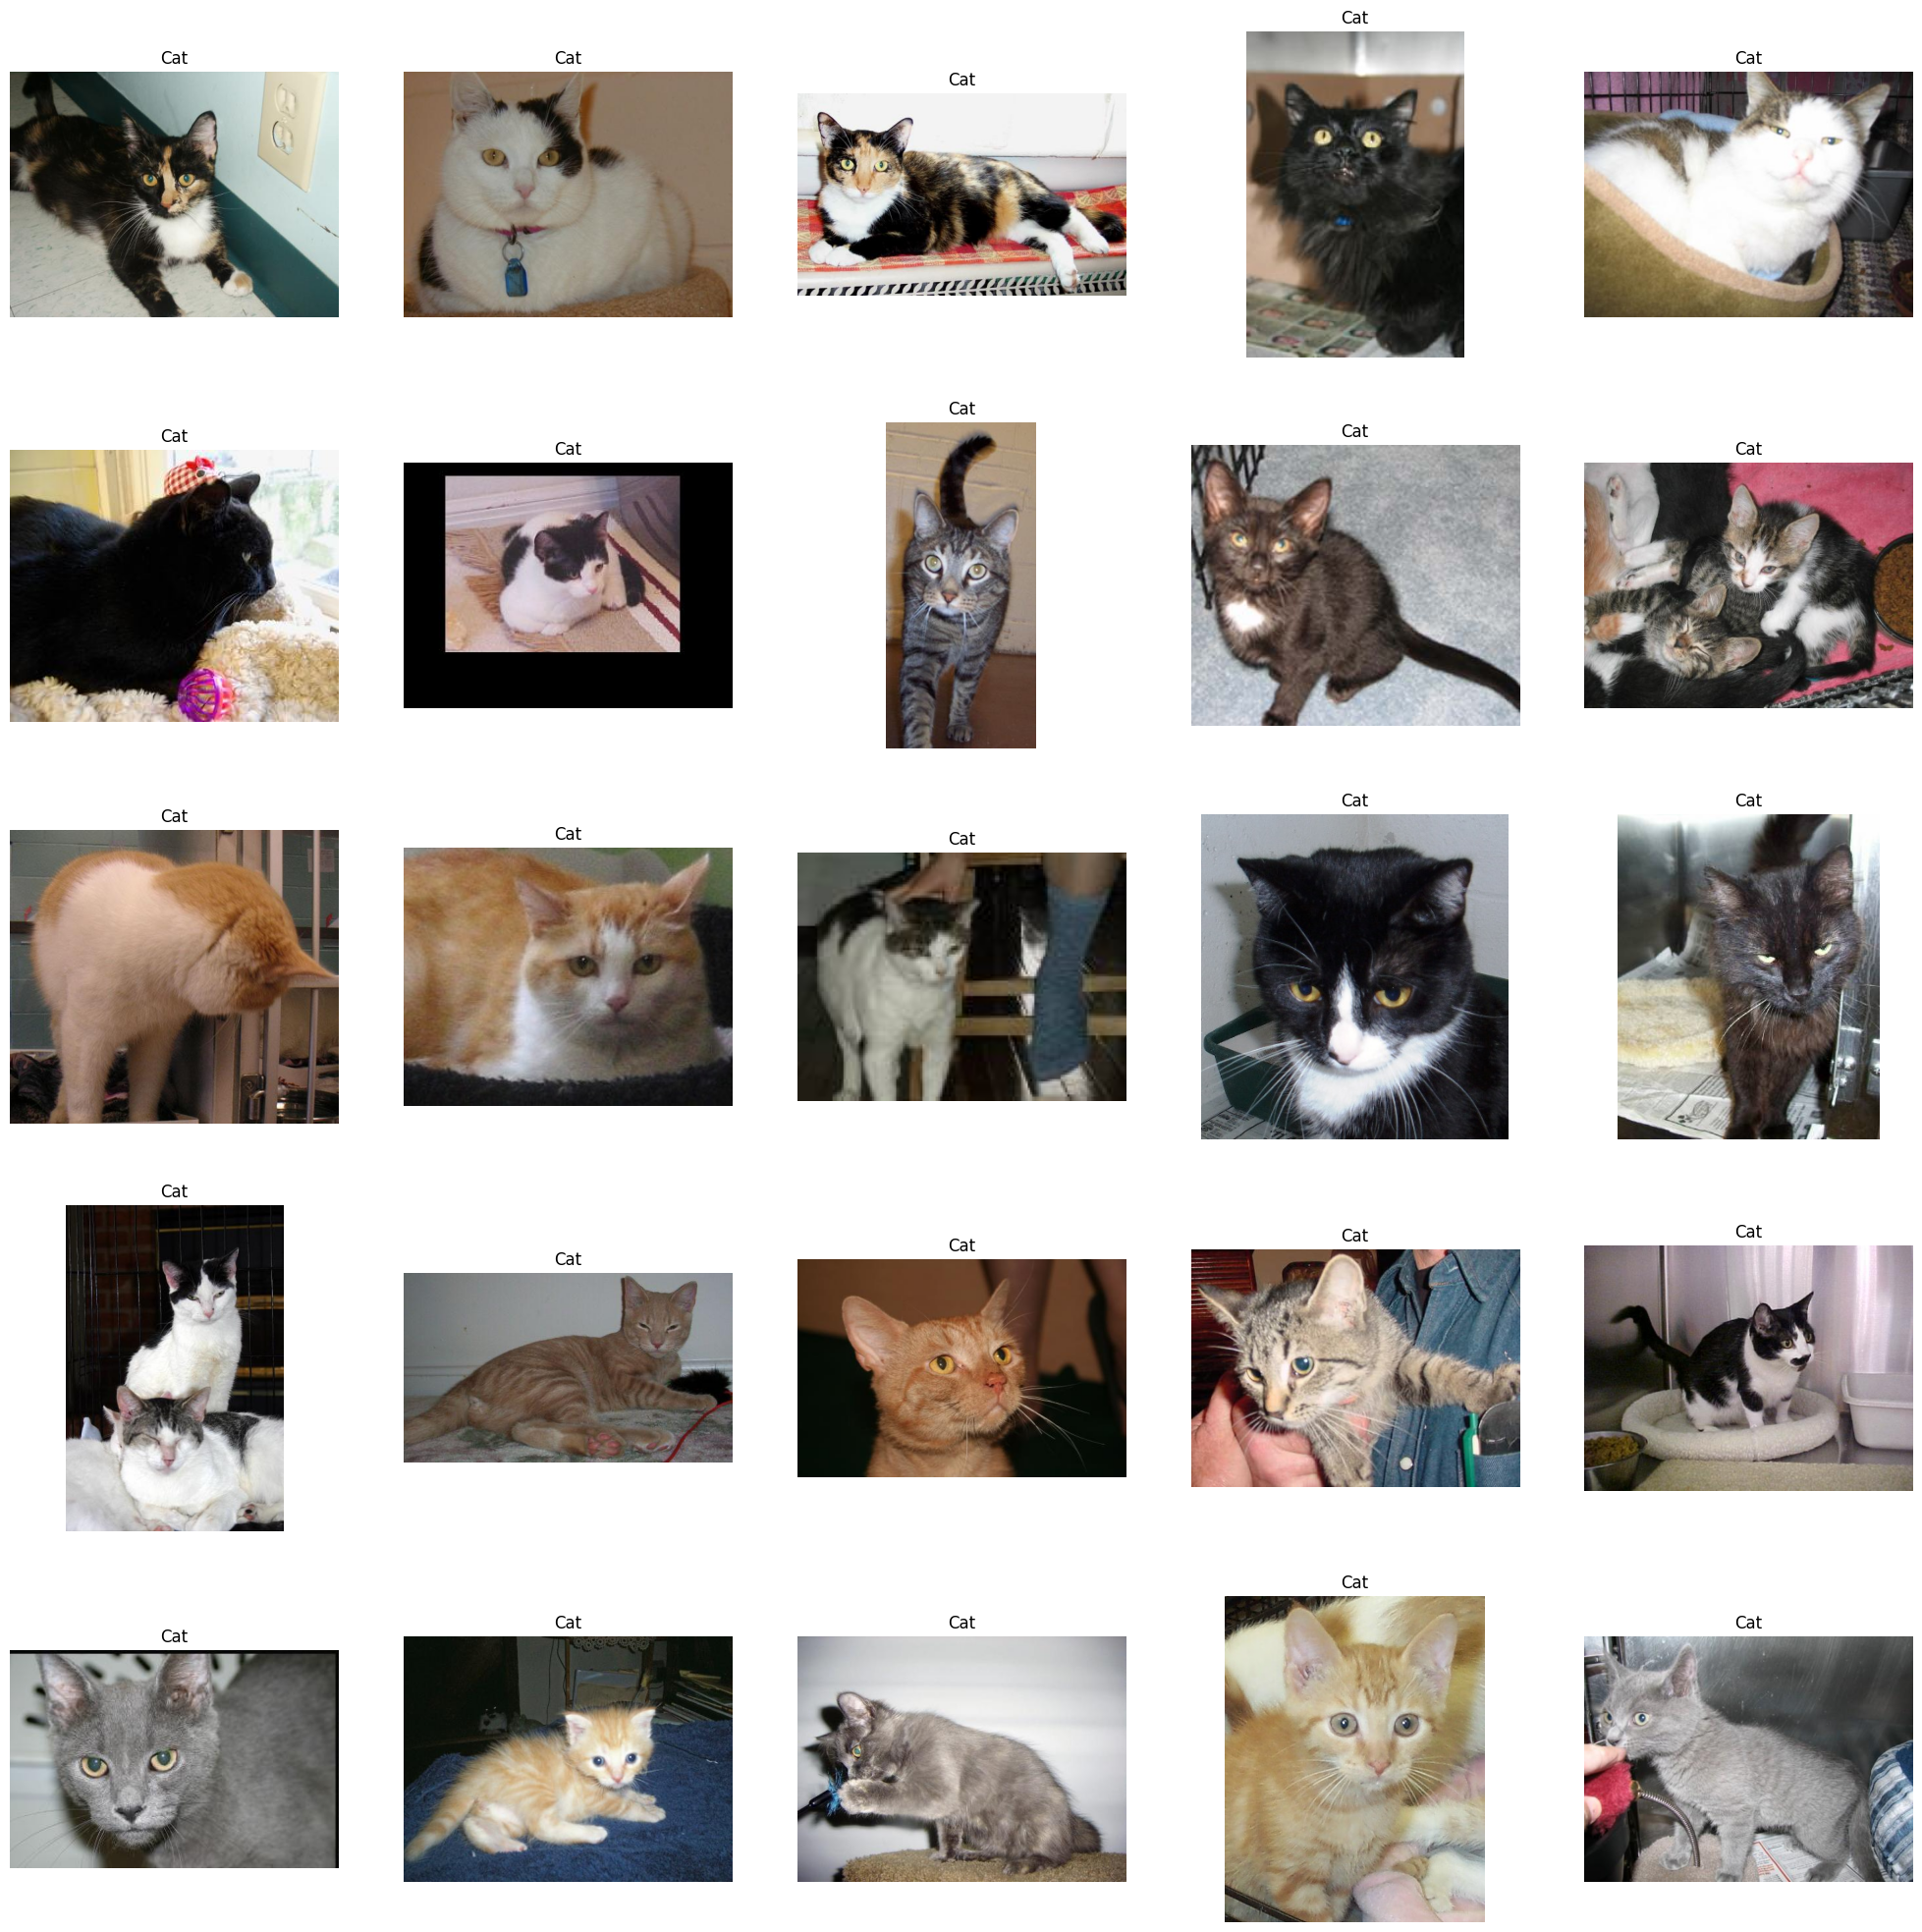

In [172]:
# Display grids of images
plt.figure(figsize=(25,25))
temp = df[df['label'] == 0]['images']
start = random.randint(0, len(temp))
files = temp[start:start+25]

for index, file in enumerate(files):
    plt.subplot(5, 5, index + 1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title('Cat')
    plt.axis('off')

<Axes: xlabel='label', ylabel='count'>

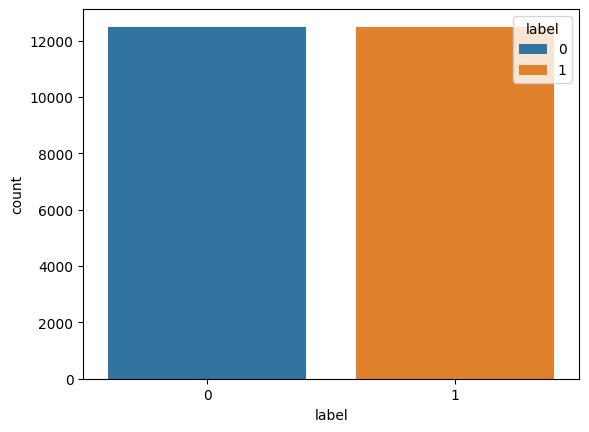

In [173]:
sns.countplot(x='label', data=df, hue = 'label')

In [174]:
df['label'] = df['label'].astype('str')

In [175]:
df.head()

,images,label
0,C:/Users/Admin/Desktop/22-Machine_Learning-Pro...,0
1,C:/Users/Admin/Desktop/22-Machine_Learning-Pro...,0
2,C:/Users/Admin/Desktop/22-Machine_Learning-Pro...,0
3,C:/Users/Admin/Desktop/22-Machine_Learning-Pro...,0
4,C:/Users/Admin/Desktop/22-Machine_Learning-Pro...,1


# 3. Train, Test, Model

In [176]:
train, test = train_test_split(df, test_size = 0.2, random_state = 42)
print(train.shape)
test.shape

(19998, 2)


(5000, 2)

In [177]:
train_generator = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 40,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode = 'nearest'
)

val_generator = ImageDataGenerator(rescale = 1./255)

train_iterator = train_generator.flow_from_dataframe(
    train,
    x_col = 'images',
    y_col = 'label',
    target_size = (128, 128),
    batch_size = 512,
    class_mode = 'binary'
)

val_iterator = val_generator.flow_from_dataframe(
    test,
    x_col = 'images',
    y_col = 'label',
    target_size = (128, 128),
    batch_size = 512,
    class_mode = 'binary'
)

Found 19998 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.


In [178]:
model = Sequential([
    Conv2D(16, (3, 3), activation = 'relu', input_shape = (128, 128, 3)),
    MaxPool2D((2, 2)),
    Conv2D(32, (3, 3), activation = 'relu'),
    MaxPool2D((2, 2)),
    Conv2D(64, (3, 3), activation = 'relu'),
    MaxPool2D((2, 2)),
    Flatten(),
    Dense(512, activation = 'relu'),
    Dense(1, activation = 'sigmoid')
])

In [179]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,447,137 (24.59 MB)

 Trainable params: 6,447,137 (24.59 MB)

 Non-trainable params: 0 (0.00 B)

In [180]:
history = model.fit(train_iterator, epochs = 10, validation_data = val_iterator)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 169s 4s/step - accuracy: 0.5310 - loss: 0.7319 - val_accuracy: 0.6082 - val_loss: 0.6646
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.6286 - loss: 0.6446 - val_accuracy: 0.6956 - val_loss: 0.5891
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 287s 7s/step - accuracy: 0.6980 - loss: 0.5789 - val_accuracy: 0.7142 - val_loss: 0.5534
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.7219 - loss: 0.5444 - val_accuracy: 0.7408 - val_loss: 0.5119
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.7141 - loss: 0.5563 - val_accuracy: 0.7508 - val_loss: 0.5089
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 171s 4s/step - accuracy: 0.7436 - loss: 0.5171 - val_accuracy: 0.7556 - val_loss: 0.4945
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.7600 - loss: 0.4896 - val_accuracy: 0.7406 - val_loss: 0.5150
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - accuracy: 0.7712 - loss: 0.4751 - val_accuracy: 0.7766 - va

# 4. Score and Visualization

<Figure size 640x480 with 0 Axes>

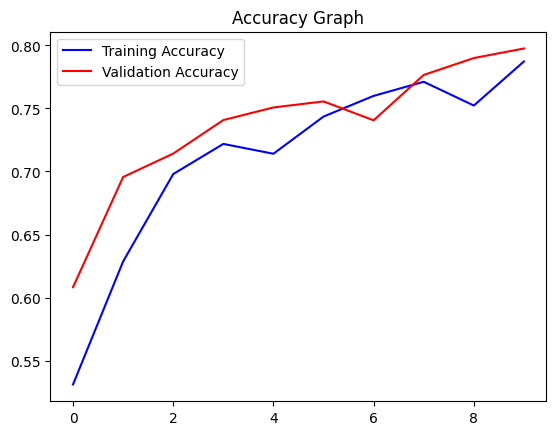

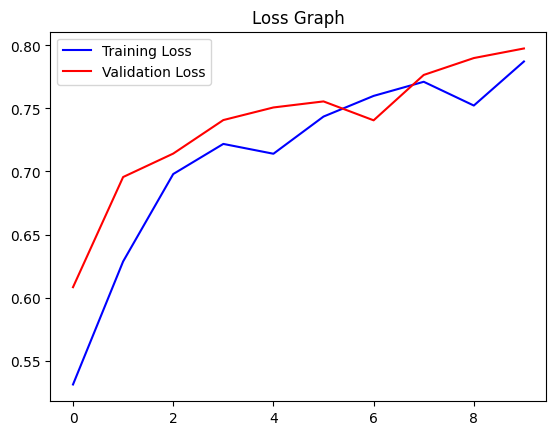

<Figure size 640x480 with 0 Axes>

In [182]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label = 'Training Accuracy')
plt.plot(epochs, val_acc, 'r', label = 'Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(epochs, acc, 'b', label = 'Training Loss')
plt.plot(epochs, val_acc, 'r', label = 'Validation Loss')
plt.title('Loss Graph')
plt.legend()
plt.figure()